In [1]:
import os
from pathlib import Path

data_dir = Path(
    "/home/qhe2/Documents/Datasets/tcia/test/"
)

model_path = Path(
    "models/stanford_v0.0.1.h5"
)

os.environ["CUDA_VISIBLE_DEVICES"] = "5"

In [2]:
import torch
os.environ["KERAS_BACKEND"] = "torch"
from keras import models
from typing import cast

model = cast(torch.nn.Module, models.load_model(model_path))
model = model.eval().cuda()

I0000 00:00:1776784707.634982 2187166 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from data import TCIA

dataset = TCIA(data_dir, batch_size=1)

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
/home/qhe2/Applications/miniconda3/envs/Comp2Comp/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
image, mask = dataset[0]
image = image.permute(1,2,0)
mask = mask.permute(1,2,0)

In [5]:
image.shape, mask.shape

(torch.Size([512, 512, 1]), torch.Size([512, 512, 1]))

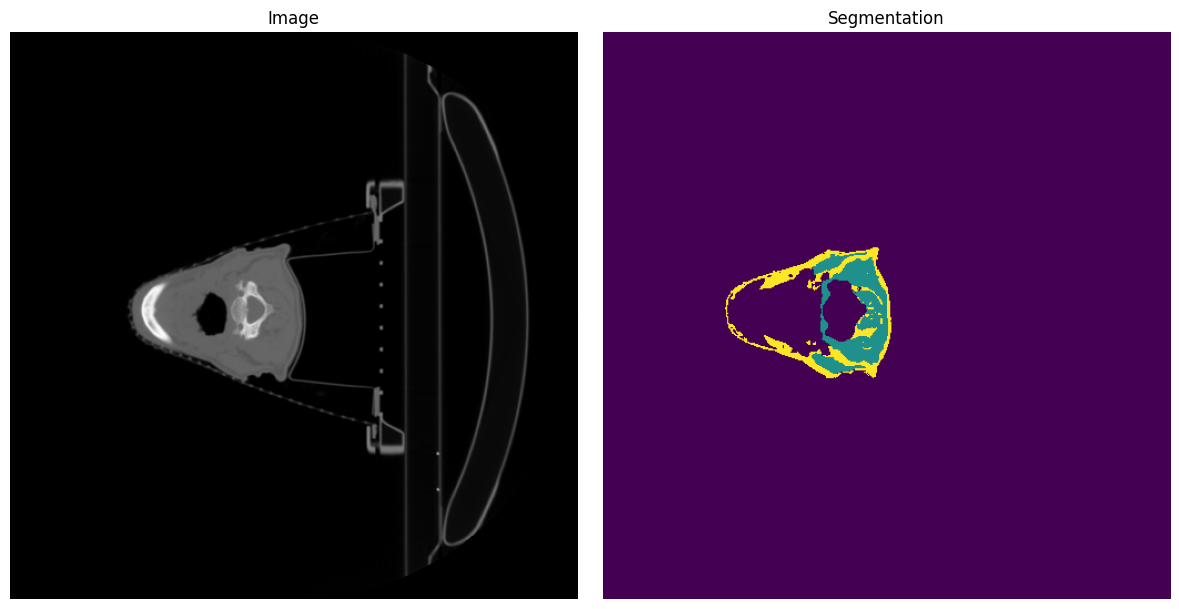

In [6]:
from matplotlib import pyplot as plt
%matplotlib inline

image_np = image.detach().cpu().squeeze().numpy()
segmentation_np = mask.detach().cpu().squeeze().numpy()

if image_np.ndim == 3:
    slice_idx = image_np.shape[0] // 2
    image_slice = image_np[slice_idx]
elif image_np.ndim == 2:
    image_slice = image_np
else:
    raise ValueError(f"Unsupported image shape: {image_np.shape}")

if segmentation_np.ndim == 3:
    segmentation_slice = segmentation_np[slice_idx]
elif segmentation_np.ndim == 2:
    segmentation_slice = segmentation_np
else:
    raise ValueError(f"Unsupported segmentation shape: {segmentation_np.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(image_slice, cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(segmentation_slice)
axes[1].set_title("Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [9]:
x = image.cuda().unsqueeze(0).expand((-1, -1, -1, 3))

In [10]:
x.shape

torch.Size([1, 512, 512, 3])

In [11]:
import torch

y: torch.Tensor = model(x)[0]
y = y.permute(2,1,0)

/home/qhe2/Applications/miniconda3/envs/Comp2Comp/lib/python3.11/site-packages/keras/src/backend/common/backend_utils.py:92: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


In [12]:
y.shape

torch.Size([5, 512, 512])

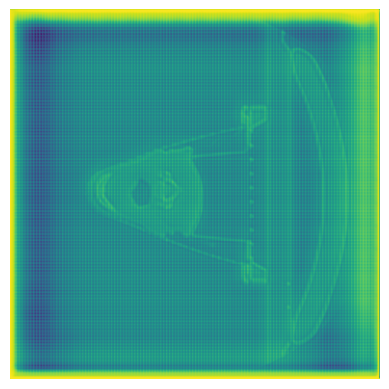

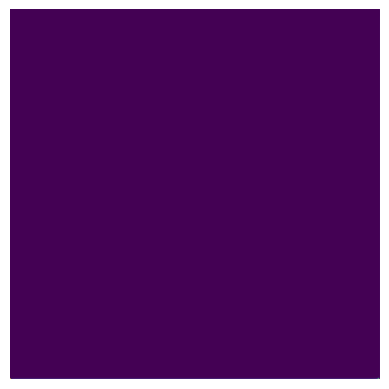

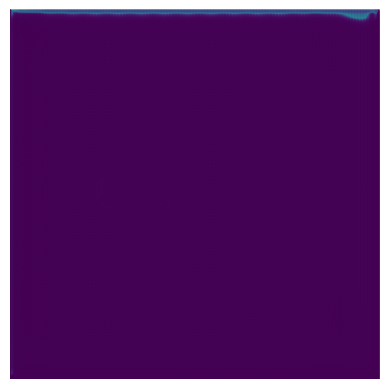

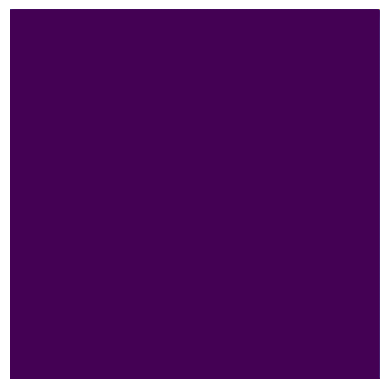

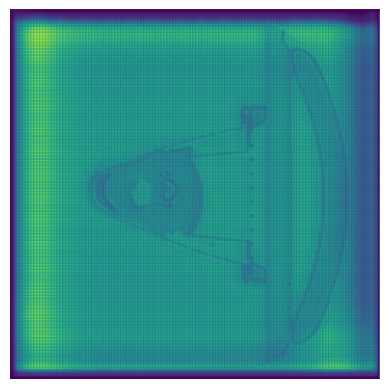

In [13]:
for m in y:
    m = m.detach().cpu().permute(1,0).squeeze().numpy()
    plt.imshow(m)
    plt.axis("off")
    plt.show()